In [42]:
import os
import pandas as pd
from pathlib import Path
import shutil

In [43]:
os.chdir('C:\\Users\\moham\\Downloads\\Projects\\Breast_Cancer_Prediction\\Dataset\\archive\\csv')
os.listdir()

['calc_case_description_test_set.csv',
 'calc_case_description_train_set.csv',
 'dicom_info.csv',
 'mass_case_description_test_set.csv',
 'mass_case_description_train_set.csv',
 'meta.csv']

In [44]:
train_data = pd.read_csv('C:\\Users\\moham\\Downloads\\Projects\\Breast_Cancer_Prediction\\Dataset\\archive\\csv\\mass_case_description_train_set.csv')
test_data = pd.read_csv('C:\\Users\\moham\\Downloads\\Projects\\Breast_Cancer_Prediction\\Dataset\\archive\\csv\\mass_case_description_test_set.csv')

In [45]:
train_data.columns

Index(['patient_id', 'breast_density', 'left or right breast', 'image view',
       'abnormality id', 'abnormality type', 'mass shape', 'mass margins',
       'assessment', 'pathology', 'subtlety', 'image file path',
       'cropped image file path', 'ROI mask file path'],
      dtype='object')

### Extract Series UID

In [46]:

def extract_uid(path):
    if pd.isna(path):
        return None
    return str(path).split('/')[-2]

# Extract UID
train_uid = train_data['image file path'].apply(extract_uid)
test_uid = test_data['image file path'].apply(extract_uid)

# Insert as first column
train_data.insert(0, 'SeriesUID', train_uid)
test_data.insert(0, 'SeriesUID', test_uid)

# Check


In [47]:
print(train_data[['SeriesUID']].head())
print(test_data[['SeriesUID']].head())

                                           SeriesUID
0  1.3.6.1.4.1.9590.100.1.2.342386194811267636608...
1  1.3.6.1.4.1.9590.100.1.2.359308329312397897125...
2  1.3.6.1.4.1.9590.100.1.2.891800462110225318343...
3  1.3.6.1.4.1.9590.100.1.2.295360926313492745441...
4  1.3.6.1.4.1.9590.100.1.2.410524754913057908920...
                                           SeriesUID
0  1.3.6.1.4.1.9590.100.1.2.245063149211255120613...
1  1.3.6.1.4.1.9590.100.1.2.859522146111705060178...
2  1.3.6.1.4.1.9590.100.1.2.221311896128932948279...
3  1.3.6.1.4.1.9590.100.1.2.239949064412092068706...
4  1.3.6.1.4.1.9590.100.1.2.215081818713600536113...


### Merge Train and Test data first

As, It is not Tabular data, no scaling or imputation has been done so, there is no risk of data Leakage. 

In [48]:
all_data = pd.concat([train_data, test_data], ignore_index=True)

In [49]:
all_data['pathology'].value_counts()

pathology
MALIGNANT                  784
BENIGN                     771
BENIGN_WITHOUT_CALLBACK    141
Name: count, dtype: int64

In [50]:
all_data_clean = all_data[all_data['pathology'] != 'BENIGN_WITHOUT_CALLBACK' ].copy()

In [51]:
all_data_clean.shape

(1555, 15)

In [52]:
jpeg_root = Path(r"C:\Users\moham\Downloads\archive\jpeg")

uids = set(all_data_clean['SeriesUID'].astype(str))

jpeg_folders = {folder.name for folder in jpeg_root.iterdir() if folder.is_dir()}

matched_uids = uids.intersection(jpeg_folders)

print("UIDs in dataframe:", len(uids))
print("JPEG folders:", len(jpeg_folders))
print("Matches:", len(matched_uids))
print("Missing:", len(uids) - len(matched_uids))

UIDs in dataframe: 1473
JPEG folders: 6774
Matches: 1473
Missing: 0


In [53]:
jpeg_root = Path(r"C:\\Users\\moham\\Downloads\\Projects\\Breast_Cancer_Prediction\\Dataset\\archive\\jpeg")
target_root = Path(r"C:\\Users\\moham\\Downloads\\Projects\\Breast_Cancer_Prediction\\Dataset\\archive\\jpeg_selected")

target_root.mkdir(exist_ok=True)

for uid in matched_uids:
    src = jpeg_root / uid
    dst = target_root / uid

    if src.exists():
        shutil.copytree(src, dst, dirs_exist_ok=True)

print(f"Copied {len(matched_uids)} folders.")

Copied 1473 folders.


In [54]:
all_data_final = all_data_clean[
    all_data_clean['SeriesUID'].isin(matched_uids)
].copy()

print(all_data_final.shape)
print(all_data_final['pathology'].value_counts())

(1555, 15)
pathology
MALIGNANT    784
BENIGN       771
Name: count, dtype: int64


In [55]:
print(all_data_final['SeriesUID'].nunique())

1473


### Duplicate Rows Issue 

All Series UID have matached but still Rows in parent file are 1555 suggesting there are 82 duplicates. Let's explore them first and then decide how we will do it? 

In [56]:
print(len(matched_uids))
print(all_data_clean['SeriesUID'].nunique())

1473
1473


In [57]:
all_data_final.shape

(1555, 15)

In [58]:
uid_counts = all_data_clean['SeriesUID'].value_counts()

duplicate_uids = uid_counts[uid_counts > 1]

print("Duplicate UIDs:", len(duplicate_uids))
print(duplicate_uids.head(5))

Duplicate UIDs: 59
SeriesUID
1.3.6.1.4.1.9590.100.1.2.87251504411596839017815563663575708222     6
1.3.6.1.4.1.9590.100.1.2.354587724213018641829708719832963731890    5
1.3.6.1.4.1.9590.100.1.2.101999469712679926627011488331183444331    4
1.3.6.1.4.1.9590.100.1.2.292605978712963936606864280561587921668    4
1.3.6.1.4.1.9590.100.1.2.122014842013197980401803659680241641105    3
Name: count, dtype: int64


In [59]:
dup_rows = all_data_clean[
    all_data_clean['SeriesUID'].isin(duplicate_uids.index)
].sort_values('SeriesUID')

dup_rows.head(5)

,SeriesUID,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
26,1.3.6.1.4.1.9590.100.1.2.101999469712679926627...,P_00044,2,RIGHT,CC,1,mass,OVAL,CIRCUMSCRIBED,3,BENIGN,5,Mass-Training_P_00044_RIGHT_CC/1.3.6.1.4.1.959...,Mass-Training_P_00044_RIGHT_CC_1/1.3.6.1.4.1.9...,Mass-Training_P_00044_RIGHT_CC_1/1.3.6.1.4.1.9...
27,1.3.6.1.4.1.9590.100.1.2.101999469712679926627...,P_00044,2,RIGHT,CC,2,mass,OVAL,CIRCUMSCRIBED,3,BENIGN,5,Mass-Training_P_00044_RIGHT_CC/1.3.6.1.4.1.959...,Mass-Training_P_00044_RIGHT_CC_2/1.3.6.1.4.1.9...,Mass-Training_P_00044_RIGHT_CC_2/1.3.6.1.4.1.9...
28,1.3.6.1.4.1.9590.100.1.2.101999469712679926627...,P_00044,2,RIGHT,CC,3,mass,OVAL,CIRCUMSCRIBED,3,BENIGN,5,Mass-Training_P_00044_RIGHT_CC/1.3.6.1.4.1.959...,Mass-Training_P_00044_RIGHT_CC_3/1.3.6.1.4.1.9...,Mass-Training_P_00044_RIGHT_CC_3/1.3.6.1.4.1.9...
29,1.3.6.1.4.1.9590.100.1.2.101999469712679926627...,P_00044,2,RIGHT,CC,4,mass,LOBULATED,CIRCUMSCRIBED,3,BENIGN,5,Mass-Training_P_00044_RIGHT_CC/1.3.6.1.4.1.959...,Mass-Training_P_00044_RIGHT_CC_4/1.3.6.1.4.1.9...,Mass-Training_P_00044_RIGHT_CC_4/1.3.6.1.4.1.9...
310,1.3.6.1.4.1.9590.100.1.2.108388395511926748633...,P_00432,1,LEFT,MLO,2,mass,IRREGULAR,SPICULATED,4,MALIGNANT,3,Mass-Training_P_00432_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00432_LEFT_MLO_2/1.3.6.1.4.1.9...,Mass-Training_P_00432_LEFT_MLO_2/1.3.6.1.4.1.9...


The duplicates are for the same patient ID and are depending on the abnormalities. As our task is to classify Benign from Malignant, that's whu we will drop the duplicates keeping only one input to Target. 

In [60]:
all_data_image = all_data_clean.drop_duplicates(
    subset=['SeriesUID']
).copy()

In [61]:
all_data_image.shape

(1473, 15)

Image Processing
----

In [62]:
print("Unique patients:", all_data_final['patient_id'].nunique())

Unique patients: 822


In [63]:
all_data_final.groupby('patient_id')['pathology'].nunique()

patient_id
P_00001    1
P_00004    1
P_00009    1
P_00015    1
P_00016    1
          ..
P_01981    1
P_01983    1
P_02033    1
P_02079    1
P_02092    1
Name: pathology, Length: 822, dtype: int64

In [64]:
all_data_final.groupby('patient_id').size()

patient_id
P_00001    2
P_00004    3
P_00009    2
P_00015    1
P_00016    2
          ..
P_01981    2
P_01983    1
P_02033    2
P_02079    2
P_02092    2
Length: 822, dtype: int64

In [65]:
patient_pathology = all_data_final.groupby('patient_id')['pathology'].nunique()

print("Patients with >1 pathology:")
print((patient_pathology > 1).sum())

Patients with >1 pathology:
14


In [66]:
patient_pathology = all_data_final.groupby('patient_id')['pathology'].nunique()

mixed_patients = patient_pathology[patient_pathology > 1].index

for patient_id in mixed_patients:
    print(f"\nPatient ID: {patient_id}")
    print(
        all_data_final[
            all_data_final['patient_id'] == patient_id
        ][['SeriesUID', 'pathology']]
    )


Patient ID: P_00160
                                             SeriesUID  pathology
118  1.3.6.1.4.1.9590.100.1.2.192830829713156688526...  MALIGNANT
119  1.3.6.1.4.1.9590.100.1.2.305474508013164328209...  MALIGNANT
120  1.3.6.1.4.1.9590.100.1.2.103311533911270368932...     BENIGN
121  1.3.6.1.4.1.9590.100.1.2.340775804311000418009...     BENIGN

Patient ID: P_00419
                                             SeriesUID  pathology
286  1.3.6.1.4.1.9590.100.1.2.175043772610570804328...     BENIGN
287  1.3.6.1.4.1.9590.100.1.2.175043772610570804328...  MALIGNANT
288  1.3.6.1.4.1.9590.100.1.2.727246052124129251237...  MALIGNANT
289  1.3.6.1.4.1.9590.100.1.2.727246052124129251237...     BENIGN
290  1.3.6.1.4.1.9590.100.1.2.243518844011228052739...     BENIGN
291  1.3.6.1.4.1.9590.100.1.2.639840744110942940280...     BENIGN

Patient ID: P_00596
                                             SeriesUID  pathology
418  1.3.6.1.4.1.9590.100.1.2.184457361110630942322...     BENIGN
419  1.3.6.1.

In [67]:
mixed_patients = patient_pathology[patient_pathology > 1].index

for patient_id in mixed_patients:
    print("\n" + "="*80)
    print("Patient:", patient_id)

    display(
        all_data_final[
            all_data_final['patient_id'] == patient_id
        ][[
            'SeriesUID',
            'left or right breast',
            'image view',
            'abnormality id',
            'pathology'
        ]]
    )


Patient: P_00160


,SeriesUID,left or right breast,image view,abnormality id,pathology
118,1.3.6.1.4.1.9590.100.1.2.192830829713156688526...,LEFT,CC,1,MALIGNANT
119,1.3.6.1.4.1.9590.100.1.2.305474508013164328209...,LEFT,MLO,1,MALIGNANT
120,1.3.6.1.4.1.9590.100.1.2.103311533911270368932...,RIGHT,CC,1,BENIGN
121,1.3.6.1.4.1.9590.100.1.2.340775804311000418009...,RIGHT,MLO,1,BENIGN



Patient: P_00419


,SeriesUID,left or right breast,image view,abnormality id,pathology
286,1.3.6.1.4.1.9590.100.1.2.175043772610570804328...,LEFT,CC,1,BENIGN
287,1.3.6.1.4.1.9590.100.1.2.175043772610570804328...,LEFT,CC,2,MALIGNANT
288,1.3.6.1.4.1.9590.100.1.2.727246052124129251237...,LEFT,MLO,1,MALIGNANT
289,1.3.6.1.4.1.9590.100.1.2.727246052124129251237...,LEFT,MLO,2,BENIGN
290,1.3.6.1.4.1.9590.100.1.2.243518844011228052739...,RIGHT,CC,1,BENIGN
291,1.3.6.1.4.1.9590.100.1.2.639840744110942940280...,RIGHT,MLO,1,BENIGN



Patient: P_00596


...

,SeriesUID,left or right breast,image view,abnormality id,pathology
1646,1.3.6.1.4.1.9590.100.1.2.406152385910425726329...,RIGHT,CC,1,MALIGNANT
1647,1.3.6.1.4.1.9590.100.1.2.462829403104100447070...,RIGHT,MLO,1,BENIGN



Patient: P_01644


,SeriesUID,left or right breast,image view,abnormality id,pathology
1142,1.3.6.1.4.1.9590.100.1.2.689976205122366323175...,LEFT,CC,1,BENIGN
1143,1.3.6.1.4.1.9590.100.1.2.373282707011960449216...,LEFT,MLO,1,BENIGN
1144,1.3.6.1.4.1.9590.100.1.2.426585149212376352035...,RIGHT,CC,1,MALIGNANT
1145,1.3.6.1.4.1.9590.100.1.2.150586274112163348618...,RIGHT,MLO,1,MALIGNANT



Patient: P_01800


,SeriesUID,left or right breast,image view,abnormality id,pathology
1684,1.3.6.1.4.1.9590.100.1.2.159593717111637608173...,LEFT,CC,1,MALIGNANT
1685,1.3.6.1.4.1.9590.100.1.2.296793691211243286711...,LEFT,MLO,1,MALIGNANT
1686,1.3.6.1.4.1.9590.100.1.2.257796728813960468725...,RIGHT,CC,1,BENIGN


In [68]:
breast_pathology = (
    all_data_final
    .groupby(['patient_id', 'left or right breast'])['pathology']
    .nunique()
)

conflicting_breasts = breast_pathology[
    breast_pathology > 1
]

print("Conflicting breasts:", len(conflicting_breasts))

Conflicting breasts: 5


In [69]:
conflicting_pairs = set(conflicting_breasts.index)

mask = all_data_image.apply(
    lambda row: (
        row['patient_id'],
        row['left or right breast']
    ) not in conflicting_pairs,
    axis=1
)

all_data_filtered = all_data_image[mask].copy()

In [70]:
all_data_filtered.shape

(1463, 15)

In [71]:
keep_uids = set(all_data_filtered['SeriesUID'].astype(str))

deleted = 0

for folder in target_root.iterdir():

    if folder.is_dir():

        if folder.name not in keep_uids:

            shutil.rmtree(folder)
            deleted += 1

print(f"Deleted {deleted} folders")
print(f"Remaining folders should be {len(keep_uids)}")

Deleted 0 folders
Remaining folders should be 1463


In [72]:
all_data_filtered.groupby('patient_id').size().describe()

count    819.000000
mean       1.786325
std        0.565520
min        1.000000
25%        1.000000
50%        2.000000
75%        2.000000
max        4.000000
dtype: float64

In [73]:
all_data_filtered['patient_id'].value_counts().head(20)

patient_id
P_00711    4
P_00820    4
P_00224    4
P_00710    4
P_00021    4
P_00596    4
P_00332    4
P_00160    4
P_00303    4
P_00391    4
P_00173    4
P_01270    4
P_01394    4
P_01644    4
P_01712    4
P_00092    4
P_01739    4
P_00515    3
P_01090    3
P_00004    3
Name: count, dtype: int64

In [74]:
from sklearn.model_selection import train_test_split
from pathlib import Path

patients = all_data_filtered['patient_id'].unique()

train_patients, test_patients = train_test_split(
    patients,
    test_size=0.2,
    random_state=42,
    stratify=all_data_filtered.groupby('patient_id')['pathology'].first()
)


train_df = all_data_filtered[
    all_data_filtered['patient_id'].isin(train_patients)
].copy()

test_df = all_data_filtered[
    all_data_filtered['patient_id'].isin(test_patients)
].copy()

y_train = (train_df['pathology'] == 'MALIGNANT').astype(int)
y_test = (test_df['pathology'] == 'MALIGNANT').astype(int)


X_train = [
    str(target_root / uid)
    for uid in train_df['SeriesUID']
]

X_test = [
    str(target_root / uid)
    for uid in test_df['SeriesUID']
]

print("Train patients:", len(train_patients))
print("Test patients:", len(test_patients))

print("Train images:", len(X_train))
print("Test images:", len(X_test))

print("Train malignant:", y_train.sum())
print("Test malignant:", y_test.sum())

Train patients: 655
Test patients: 164
Train images: 1164
Test images: 299
Train malignant: 589
Test malignant: 149


In [75]:
from pathlib import Path
from collections import Counter
counts = Counter()
missing, multi = [], []
for p in X_train + X_test:
    imgs = list(Path(p).glob("*.jpg")) + list(Path(p).glob("*.png"))
    counts[len(imgs)] += 1
    if len(imgs) == 0: missing.append(p)
    if len(imgs) > 1:  multi.append((p, len(imgs)))
print("images-per-folder distribution:", dict(counts))
print("empty folders:", len(missing))
print("multi-image folders:", len(multi))

images-per-folder distribution: {1: 1463}
empty folders: 0
multi-image folders: 0


In [76]:
from pathlib import Path
from PIL import Image
import pandas as pd, numpy as np

rows = []
for p in X_train + X_test:
    f = (list(Path(p).glob("*.jpg")) + list(Path(p).glob("*.png")))[0]
    with Image.open(f) as im:
        w, h = im.size
        rows.append({'path': p, 'mode': im.mode, 'w': w, 'h': h,
                     'aspect': h / w, 'megapixels': (w * h) / 1e6})

dims = pd.DataFrame(rows)

print("modes:", dims['mode'].value_counts().to_dict())
print("\nwidth / height summary:")
print(dims[['w', 'h', 'aspect', 'megapixels']].describe(percentiles=[.05,.25,.5,.75,.95]))
print("\nunique (w,h) pairs:", dims.groupby(['w','h']).size().sort_values(ascending=False).head(10))
print("\nportrait (h>w):", (dims['h'] > dims['w']).sum(),
      "| landscape:", (dims['w'] >= dims['h']).sum())
print("smallest side ever:", dims[['w','h']].min().min())

modes: {'L': 1463}

width / height summary:
                 w            h       aspect   megapixels
count  1463.000000  1463.000000  1463.000000  1463.000000
mean   3120.230349  5321.714286     1.732994    16.856364
std     548.872493   681.389788     0.235543     4.793794
min    1786.000000  3920.000000     1.204035     7.395076
5%     2352.400000  4512.000000     1.423805    11.501829
25%    2720.000000  4712.000000     1.549553    13.008054
50%    3000.000000  5281.000000     1.703170    14.839680
75%    3526.000000  5836.000000     1.869117    21.034942
95%    4071.400000  6646.000000     2.168823    24.854785
max    5431.000000  6931.000000     2.990482    37.316401

unique (w,h) pairs: w     h   
2776  5491    4
2648  4712    3
2911  5491    3
2296  5491    3
2611  5491    3
2521  5236    3
2761  5266    3
3106  5491    3
3121  5491    3
2768  4640    2
dtype: int64

portrait (h>w): 1463 | landscape: 0
smallest side ever: 1786


In [77]:
from pathlib import Path
from PIL import Image
import numpy as np, pandas as pd

def first_img(folder):
    return (list(Path(folder).glob("*.jpg")) + list(Path(folder).glob("*.png")))[0]

stats = []
for p in X_train + X_test:
    with Image.open(first_img(p)) as im:
        im.draft('L', (im.width // 6, im.height // 6))     # fast approx downscale
        a = np.asarray(im.convert('L'), dtype=np.float32)
    cs = max(a.shape) // 10
    corners = np.concatenate([a[:cs,:cs].ravel(), a[:cs,-cs:].ravel(),
                              a[-cs:,:cs].ravel(), a[-cs:,-cs:].ravel()])
    stats.append({'path': p, 'min': a.min(), 'max': a.max(), 'mean': a.mean(),
                  'std': a.std(), 'corner_med': np.median(corners),
                  'frac_bright': (a > 230).mean()})

S = pd.DataFrame(stats)
print("INVERTED? (bright background, corner_med>40):", (S['corner_med'] > 40).sum())
print("blank/constant (std<3):", (S['std'] < 3).sum())
print("low dynamic range (max<200):", (S['max'] < 200).sum())
print("big bright area >25% (burned-in label?):", (S['frac_bright'] > 0.25).sum())
print(S[['min','max','mean','std','corner_med','frac_bright']].describe())

INVERTED? (bright background, corner_med>40): 62
blank/constant (std<3): 0
low dynamic range (max<200): 5
big bright area >25% (burned-in label?): 0
               min          max         mean          std   corner_med  \
count  1463.000000  1463.000000  1463.000000  1463.000000  1463.000000   
mean      0.003418   253.475052    54.320164    64.765701     5.572112   
std       0.130722     7.030753    17.791925    10.911303    22.036697   
min       0.000000   173.000000    11.429379    33.097828     0.000000   
25%       0.000000   255.000000    41.621546    57.349962     0.000000   
50%       0.000000   255.000000    52.999119    64.853401     0.000000   
75%       0.000000   255.000000    66.824333    71.963120     0.000000   
max       5.000000   255.000000   128.413483    94.055428   215.000000   

       frac_bright  
count  1463.000000  
mean      0.010648  
std       0.015378  
min       0.000000  
25%       0.001029  
50%       0.004766  
75%       0.013234  
max       0.1242

flagged: 62


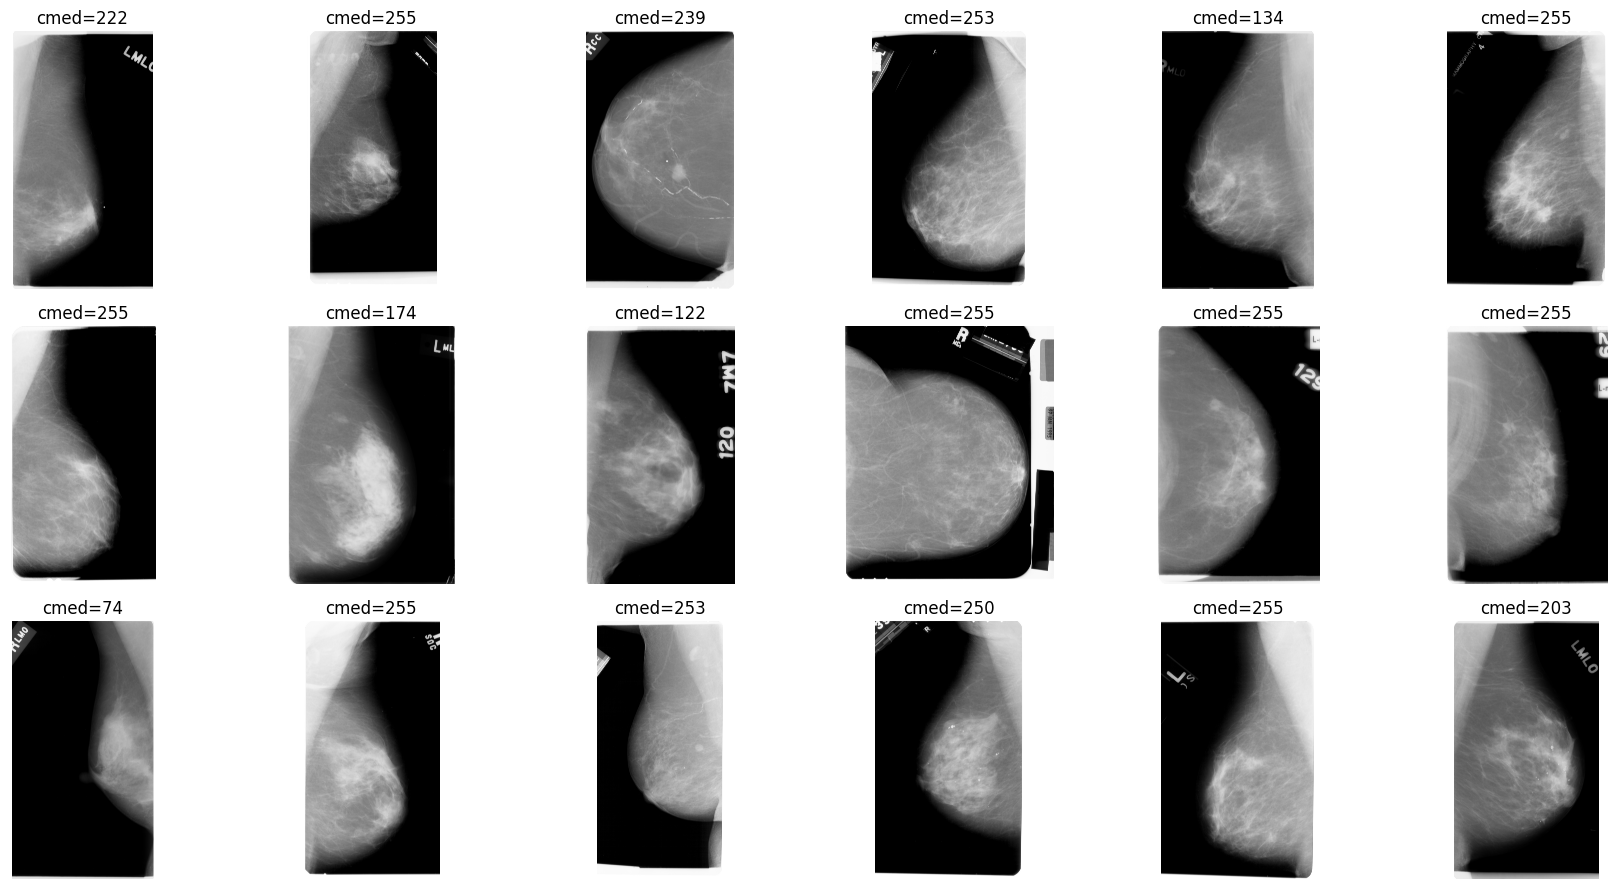

In [82]:
import matplotlib.pyplot as plt, numpy as np
flagged = S[S['corner_med'] > 40]['path'].tolist()
print("flagged:", len(flagged))

fig, ax = plt.subplots(3, 6, figsize=(18, 9))
for i, p in enumerate(flagged[:18]):
    a = load_gray(p)
    ax.flat[i].imshow(a, cmap='gray'); ax.flat[i].axis('off')
    ax.flat[i].set_title(f"cmed={int(np.median(np.r_[a[:50,:50].ravel(), a[-50:,-50:].ravel()]))}")
plt.tight_layout(); plt.show()

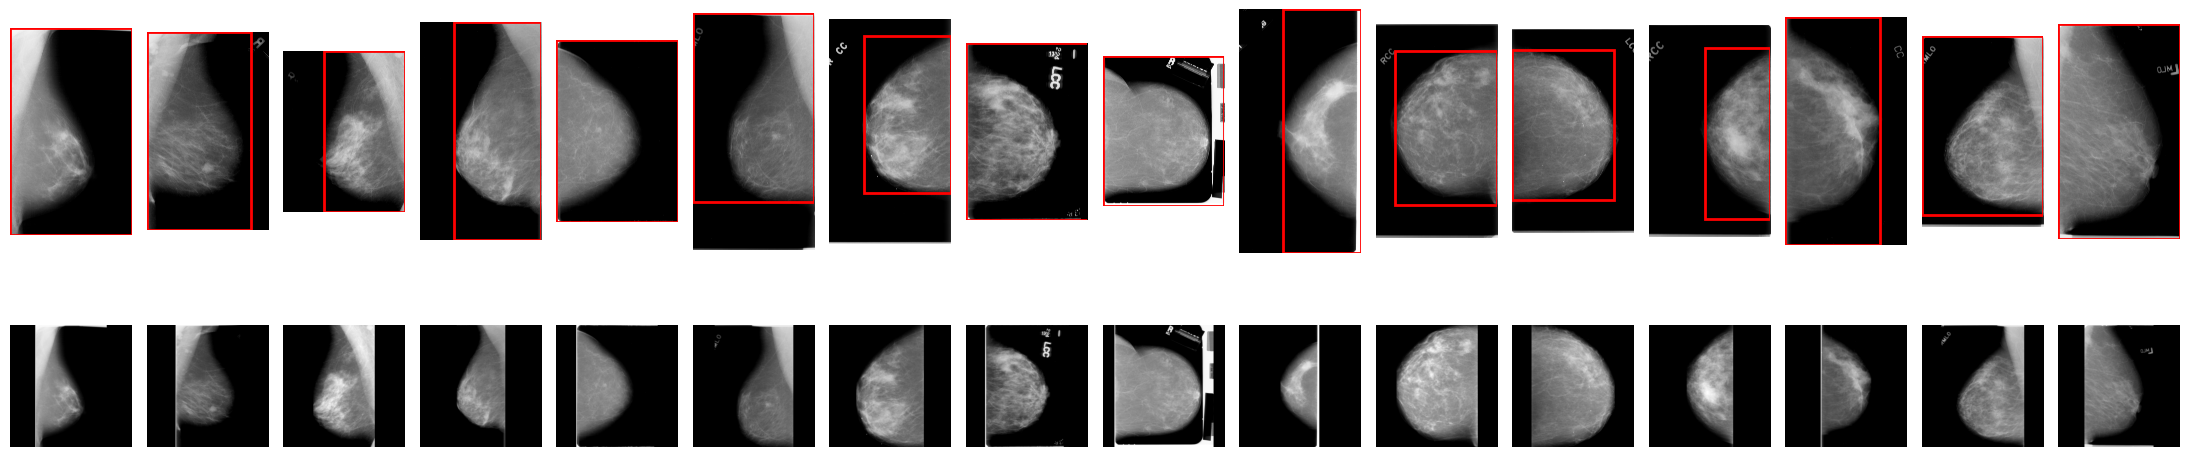

In [80]:
import matplotlib.pyplot as plt, random
from PIL import ImageOps
from skimage.filters import threshold_otsu          # pip install scikit-image if needed
from scipy import ndimage as ndi

def load_gray(folder):
    return np.asarray(Image.open(first_img(folder)).convert('L'))

def breast_bbox(a):
    mask = a > threshold_otsu(a)
    lbl, n = ndi.label(mask)                          # keep LARGEST component →
    if n == 0: return 0, 0, a.shape[1], a.shape[0]    # ignores detached white tags
    biggest = 1 + np.argmax(ndi.sum(np.ones_like(lbl), lbl, range(1, n+1)))
    ys, xs = np.where(lbl == biggest)
    return xs.min(), ys.min(), xs.max()+1, ys.max()+1

def preprocess(a, size=512):
    x0,y0,x1,y1 = breast_bbox(a)
    crop = Image.fromarray(a[y0:y1, x0:x1])
    return np.asarray(ImageOps.pad(crop, (size, size),         # resize+pad in one
                                   method=Image.LANCZOS, color=0))

samp = random.sample(X_train, 16)
fig, ax = plt.subplots(2, 16, figsize=(22, 6))
for i, p in enumerate(samp):
    a = load_gray(p); x0,y0,x1,y1 = breast_bbox(a)
    ax[0,i].imshow(a, cmap='gray')
    ax[0,i].add_patch(plt.Rectangle((x0,y0), x1-x0, y1-y0, ec='r', fc='none', lw=2))
    ax[1,i].imshow(preprocess(a), cmap='gray')
    for r in (0,1): ax[r,i].axis('off')
ax[0,0].set_ylabel('orig+bbox'); ax[1,0].set_ylabel('512²')
plt.tight_layout(); plt.show()

In [83]:
import pandas as pd
qc = []
for p in X_train + X_test:
    a = load_gray(p); H, W = a.shape
    x0,y0,x1,y1 = breast_bbox(a); bw, bh = x1-x0, y1-y0
    box = a[y0:y1, x0:x1]
    fg = (box > threshold_otsu(a)).mean() if box.size else 0
    qc.append({'path': p, 'box_frac': (bw*bh)/(W*H),
               'box_w_frac': bw/W, 'fg_in_box': fg})
Q = pd.DataFrame(qc)
print(Q.describe(percentiles=[.01,.05,.5,.95,.99]))
print("sliver/empty (box_frac<0.05):", (Q['box_frac']<0.05).sum())   # crop collapsed
print("did nothing (box_frac>0.95):", (Q['box_frac']>0.95).sum())    # box = whole image
print("low fill (fg<0.3):", (Q['fg_in_box']<0.3).sum())              # box not hugging tissue

          box_frac   box_w_frac    fg_in_box
count  1463.000000  1463.000000  1463.000000
mean      0.790504     0.830611     0.496968
std       0.226815     0.199315     0.129470
min       0.077465     0.167484     0.050774
1%        0.225158     0.337218     0.195131
5%        0.373356     0.457148     0.279764
50%       0.856450     1.000000     0.500394
95%       1.000000     1.000000     0.704708
99%       1.000000     1.000000     0.747454
max       1.000000     1.000000     0.794003
sliver/empty (box_frac<0.05): 0
did nothing (box_frac>0.95): 614
low fill (fg<0.3): 101


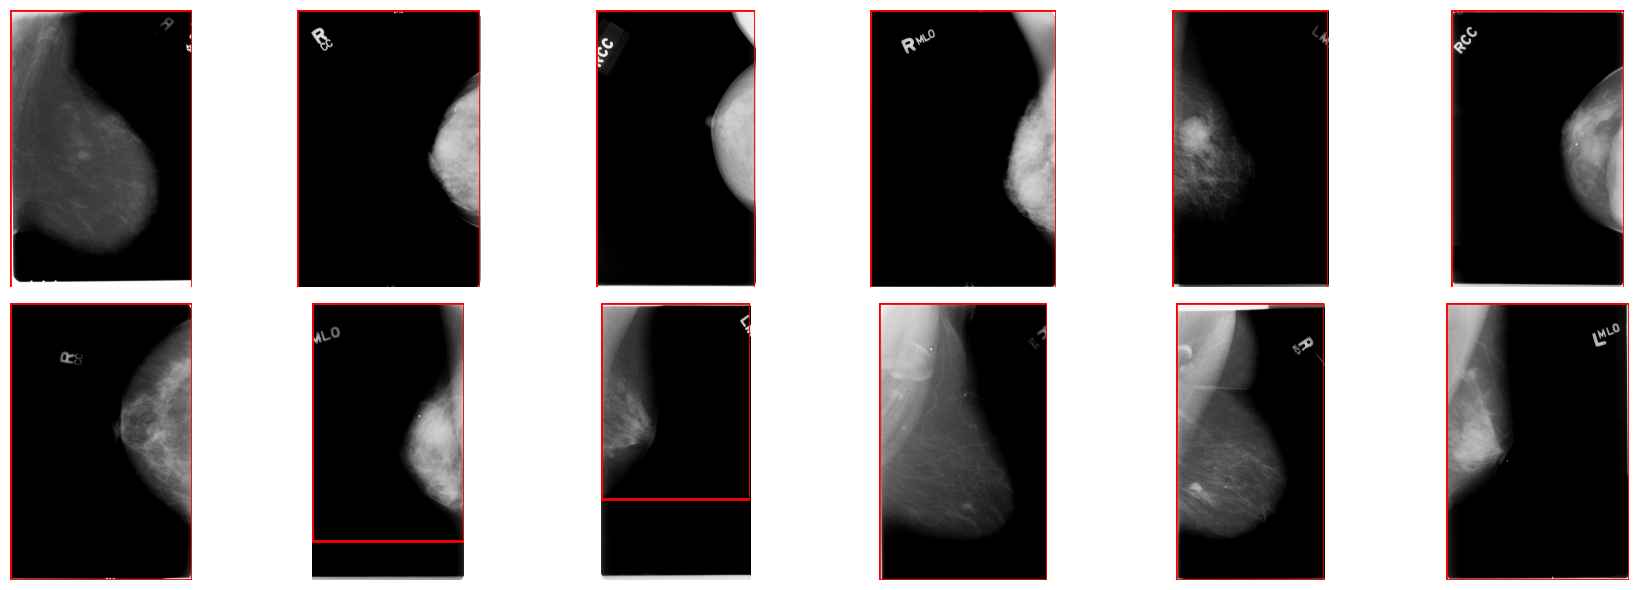

In [84]:
import matplotlib.pyplot as plt
suspect = Q[(Q['fg_in_box'] < 0.3)].sort_values('fg_in_box')['path'].head(12).tolist()
fig, ax = plt.subplots(2, 6, figsize=(18, 6))
for i, p in enumerate(suspect):
    a = load_gray(p); x0,y0,x1,y1 = breast_bbox(a)
    ax.flat[i].imshow(a, cmap='gray')
    ax.flat[i].add_patch(plt.Rectangle((x0,y0),x1-x0,y1-y0,ec='r',fc='none',lw=2))
    ax.flat[i].axis('off')
plt.tight_layout(); plt.show()

In [85]:
from pathlib import Path
from PIL import Image, ImageOps
from skimage.filters import threshold_otsu
from scipy import ndimage as ndi
import numpy as np, pandas as pd

FINAL = Path(r"C:\Users\moham\Downloads\Projects\Breast_Cancer_Prediction\Dataset\Breast_Cancer_Final")
for split in ("train", "test"):
    for cls in ("BENIGN", "MALIGNANT"):
        (FINAL / split / cls).mkdir(parents=True, exist_ok=True)

def first_img(folder):
    return (list(Path(folder).glob("*.jpg")) + list(Path(folder).glob("*.png")))[0]

def breast_bbox(a):
    mask = a > threshold_otsu(a)
    lbl, n = ndi.label(mask)
    if n == 0: return 0, 0, a.shape[1], a.shape[0]
    biggest = 1 + np.argmax(ndi.sum(np.ones_like(lbl), lbl, range(1, n+1)))
    ys, xs = np.where(lbl == biggest)
    return xs.min(), ys.min(), xs.max()+1, ys.max()+1

def preprocess(a, size=512):
    x0,y0,x1,y1 = breast_bbox(a)
    crop = Image.fromarray(a[y0:y1, x0:x1])
    return np.asarray(ImageOps.pad(crop, (size, size), method=Image.LANCZOS, color=0))

def export(df, split):
    records, done, skipped = [], 0, 0
    for _, row in df.iterrows():
        uid, cls = row['SeriesUID'], row['pathology']
        dst = FINAL / split / cls / f"{uid}.png"
        records.append({'filename': f"{cls}/{uid}.png", 'filepath': str(dst),
                        'SeriesUID': uid, 'patient_id': row['patient_id'],
                        'breast': row['left or right breast'], 'view': row['image view'],
                        'pathology': cls, 'label': int(cls == 'MALIGNANT')})
        if dst.exists():                       # resumable
            skipped += 1; continue
        a = np.asarray(Image.open(first_img(target_root / uid)).convert('L'))
        Image.fromarray(preprocess(a)).save(dst)
        done += 1
        if done % 200 == 0: print(f"  {split}: {done} written")
    pd.DataFrame(records).to_csv(FINAL / f"{split}.csv", index=False)
    print(f"{split}: {done} written, {skipped} already existed, csv saved")

export(train_df, "train")
export(test_df,  "test")

  train: 200 written
  train: 400 written
  train: 600 written
  train: 800 written
  train: 1000 written
train: 1164 written, 0 already existed, csv saved
  test: 200 written
test: 299 written, 0 already existed, csv saved


In [86]:
from pathlib import Path
from PIL import Image
import pandas as pd, random

FINAL = Path(r"C:\Users\moham\Downloads\Projects\Breast_Cancer_Prediction\Dataset\Breast_Cancer_Final")

# 1. per-class file counts
for split, (b, m) in [("train", (575, 589)), ("test", (150, 149))]:
    nb = len(list((FINAL/split/"BENIGN").glob("*.png")))
    nm = len(list((FINAL/split/"MALIGNANT").glob("*.png")))
    print(f"{split}: BENIGN {nb}/{b}, MALIGNANT {nm}/{m}",
          "✓" if (nb,nm)==(b,m) else "✗")

# 2. CSV integrity + no patient leakage across splits
tr, te = pd.read_csv(FINAL/"train.csv"), pd.read_csv(FINAL/"test.csv")
print("rows:", len(tr), len(te), "| label means:",
      round(tr.label.mean(),3), round(te.label.mean(),3))
leak = set(tr.patient_id) & set(te.patient_id)
print("patient overlap (must be 0):", len(leak))

# 3. spot-check a few PNGs actually open at 512² grayscale
for p in random.sample(list((FINAL/"train"/"MALIGNANT").glob("*.png")), 3):
    im = Image.open(p); print(p.name[:24], im.mode, im.size)

train: BENIGN 575/575, MALIGNANT 589/589 ✓
test: BENIGN 150/150, MALIGNANT 149/149 ✓
rows: 1164 299 | label means: 0.506 0.498
patient overlap (must be 0): 0
1.3.6.1.4.1.9590.100.1.2 L (512, 512)
1.3.6.1.4.1.9590.100.1.2 L (512, 512)
1.3.6.1.4.1.9590.100.1.2 L (512, 512)


In [87]:
import numpy as np
from pathlib import Path
from PIL import Image

FINAL = Path(r"C:\Users\moham\Downloads\Projects\Breast_Cancer_Prediction\Dataset\Breast_Cancer_Final")
train_pngs = list((FINAL/"train").rglob("*.png"))

s, ss, n = 0.0, 0.0, 0
for p in train_pngs:
    a = np.asarray(Image.open(p), dtype=np.float64) / 255.0
    s += a.sum(); ss += (a**2).sum(); n += a.size
mean = s / n
std  = np.sqrt(ss/n - mean**2)
print(f"train mean={mean:.4f}  std={std:.4f}")   # save these two numbers

train mean=0.1392  std=0.2370


In [89]:
pip install torchvision

   ---------------------------------------- 0.0/4.2 MB ? eta -:--:--
   ------------------------------------- -- 3.9/4.2 MB 19.9 MB/s eta 0:00:01
   ---------------------------------------- 4.2/4.2 MB 19.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   - -------------------------------------- 4.2/123.0 MB 20.6 MB/s eta 0:00:06
   -- ------------------------------------- 6.8/123.0 MB 16.8 MB/s eta 0:00:07
   --- ------------------------------------ 10.5/123.0 MB 16.7 MB/s eta 0:00:07
   ---- ----------------------------------- 14.4/123.0 MB 17.8 MB/s eta 0:00:07
   ----- ---------------------------------- 16.8/123.0 MB 16.3 MB/s eta 0:00:07
   ------ --------------------------------- 18.6/123.0 MB 14.9 MB/s eta 0:00:07
   ------ --------------------------------- 20.7/123.0 MB 14.2 MB/s eta 0:00:08
   ------- -------------------------------- 22.8/123.0 MB 13.7 MB/s eta 0:00:08
   -------- ------------------------------- 25.2/123.0 MB 13.5 MB/s 

  You can safely remove it manually.


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd

MEAN, STD = mean, std   # from block above

class MammoDataset(Dataset):
    def __init__(self, csv_path, root, tf):
        self.df = pd.read_csv(csv_path); self.root = root; self.tf = tf
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = Image.open(self.root / r['filename']).convert('L')
        return self.tf(img), torch.tensor(r['label'], dtype=torch.float32)

train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomAffine(degrees=10, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([MEAN], [STD]),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),   # 1→3 ch for pretrained backbone
])
eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([MEAN], [STD]),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
])

train_ds = MammoDataset(FINAL/"train.csv", FINAL/"train", train_tf)
test_ds  = MammoDataset(FINAL/"test.csv",  FINAL/"test",  eval_tf)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

xb, yb = next(iter(train_loader))
print(xb.shape, xb.dtype, yb.shape, "| batch mean≈0:", round(xb.mean().item(), 3))

c:\Users\moham\miniconda3\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
